In [1]:
import numpy as np
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt 
from typing import Dict, Iterable, Optional, Tuple
from math import *


In [2]:
from torch import Tensor, nn
import torch.nn.functional as F
import scipy.stats
import time
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler

In [3]:
try:
    from torch.nn.functional import scaled_dot_product_attention

    SDPA_AVAILABLE = True
except (ImportError, RuntimeError, OSError):
    scaled_dot_product_attention = None
    SDPA_AVAILABLE = False

In [4]:
import torchaudio
from tqdm.notebook import tqdm

DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
DEVICE

device(type='mps')

In [5]:
data_dir = 'New_Data'

In [6]:
class CustomDataset(Dataset):
    def __init__(self, path_airs, path_indices, path_ground):
        """
        Args:
            data_airs (np.array): Array of shape (673, 187, 282, 32).
            data_indices (np.array): Array of indices corresponding to the rows in df_labels.
            df_labels (pd.DataFrame): DataFrame of shape (673, 284) containing the labels.
        """
        self.data_airs = torch.tensor( np.load(os.path.join(data_dir, path_airs), allow_pickle=True))  # Convert the data to a tensor
        self.data_indices = torch.tensor(np.load(os.path.join(data_dir, path_indices), allow_pickle=True)).long()  # Convert indices to tensor
        self.df_labels = pd.read_csv(path_ground)  # Keep df_labels as a pandas DataFrame

    def __len__(self):
        # Return the total number of samples
        return len(self.data_indices)

    def __getitem__(self, idx):
        # Get the index from data_indices
        index = self.data_indices[idx].item()  # Convert tensor to Python scalar
        
        # Select the data_airs corresponding to the index
        data_sample = self.data_airs[idx]
        
        # Select the corresponding label row where the first column matches the index
        label_row = self.df_labels[self.df_labels.iloc[:, 0] == index].iloc[0].values[1:]  # Exclude the first column (index)

        # Convert label_row to a tensor
        label = torch.tensor(label_row).float()

        return data_sample, label

# Example usage
# Assuming data_airs is the (673, 187, 282, 32) numpy array, data_indices is the indices array,
# and df_labels is the pandas DataFrame (673, 284), with the first column being the index column

# Create the dataset
path_ground =  'train_labels.csv'
path_indices = 'new_data_indices.npy'
path_airs = 'data_preprocessed.npy'
custom_dataset = CustomDataset(path_airs, path_indices, path_ground)

# Create a DataLoader to iterate over the dataset (optional)
dataloader = DataLoader(custom_dataset, batch_size=32, shuffle=True)

# Iterate through the dataset
for batch_data, batch_labels in dataloader:
    print("Batch Data Shape:", batch_data.shape)  # (batch_size, 187, 282, 32)
    print("Batch Labels Shape:", batch_labels.shape)  # (batch_size, 283) -> since we exclude the first index column
    break


Batch Data Shape: torch.Size([32, 187, 283])
Batch Labels Shape: torch.Size([32, 283])


In [7]:
print('Shape of the training datasset: \t')
print('\n For AIRS-CH0:', batch_data.shape)
print('\n Labels:', batch_labels.shape)

Shape of the training datasset: 	

 For AIRS-CH0: torch.Size([32, 187, 283])

 Labels: torch.Size([32, 283])


In [8]:
batch_data.shape

torch.Size([32, 187, 283])

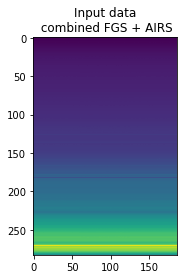

In [9]:
plt.imshow(batch_data[0,:,:].T)
plt.title('Input data\n combined FGS + AIRS')
plt.show()

/var/folders/dp/l6p51q511nbb1spwhbnzhnkc0000gs/T/ipykernel_26601/2867722626.py:1: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:3641.)
  plt.plot(batch_labels[-1].T)


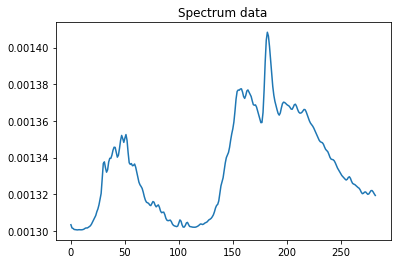

In [10]:
plt.plot(batch_labels[-1].T)
plt.title("Spectrum data")
plt.show()

In [28]:
dims_tiny= {'n_mels':283, 'n_audio_ctx':94, 'n_audio_state':384, 'n_audio_head':6, 'n_audio_layer':4/2, 'n_vocab':51865, 'n_text_ctx':448, 'n_text_state':384, 'n_text_head':6, 'n_text_layer':4/2}

In [31]:
class LayerNorm(nn.LayerNorm):
    def forward(self, x: Tensor) -> Tensor:
        return super().forward(x.float()).type(x.dtype)

    
    
class Conv1d(nn.Conv1d):
    def _conv_forward(
        self, x: Tensor, weight: Tensor, bias: Optional[Tensor]
    ) -> Tensor:
        return super()._conv_forward(
            x, weight.to(x.dtype), None if bias is None else bias.to(x.dtype)
        )

    
class Linear(nn.Linear):
    def forward(self, x: Tensor) -> Tensor:
        return F.linear(
            x,
            self.weight.to(x.dtype),
            None if self.bias is None else self.bias.to(x.dtype),
        )
    
def sinusoids(length, channels, max_timescale=10000):
    """Returns sinusoids for positional embedding"""
    assert channels % 2 == 0
    log_timescale_increment = np.log(max_timescale) / (channels // 2 - 1)
    inv_timescales = torch.exp(-log_timescale_increment * torch.arange(channels // 2))
    scaled_time = torch.arange(length)[:, np.newaxis] * inv_timescales[np.newaxis, :]
    return torch.cat([torch.sin(scaled_time), torch.cos(scaled_time)], dim=1)


class MultiHeadAttention(nn.Module):
    use_sdpa = True

    def __init__(self, n_state: int, n_head: int):
        super().__init__()
        self.n_head = n_head
        self.query = Linear(n_state, n_state)
        self.key = Linear(n_state, n_state, bias=False)
        self.value = Linear(n_state, n_state)
        self.out = Linear(n_state, n_state)

    def forward(
        self,
        x: Tensor,
        xa: Optional[Tensor] = None,
        mask: Optional[Tensor] = None,
        kv_cache: Optional[dict] = None,
    ):
        q = self.query(x)

        if kv_cache is None or xa is None or self.key not in kv_cache:
            # hooks, if installed (i.e. kv_cache is not None), will prepend the cached kv tensors;
            # otherwise, perform key/value projections for self- or cross-attention as usual.
            k = self.key(x if xa is None else xa)
            v = self.value(x if xa is None else xa)
        else:
            # for cross-attention, calculate keys and values once and reuse in subsequent calls.
            k = kv_cache[self.key]
            v = kv_cache[self.value]

        wv, qk = self.qkv_attention(q, k, v, mask)
        return self.out(wv), qk

    def qkv_attention(
        self, q: Tensor, k: Tensor, v: Tensor, mask: Optional[Tensor] = None
    ) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        n_batch, n_ctx, n_state = q.shape
        scale = (n_state // self.n_head) ** -0.25
        q = q.view(*q.shape[:2], self.n_head, -1).permute(0, 2, 1, 3)
        k = k.view(*k.shape[:2], self.n_head, -1).permute(0, 2, 1, 3)
        v = v.view(*v.shape[:2], self.n_head, -1).permute(0, 2, 1, 3)

        if SDPA_AVAILABLE and MultiHeadAttention.use_sdpa:
            a = scaled_dot_product_attention(
                q, k, v, is_causal=mask is not None and n_ctx > 1
            )
            out = a.permute(0, 2, 1, 3).flatten(start_dim=2)
            qk = None
        else:
            qk = (q * scale) @ (k * scale).transpose(-1, -2)
            if mask is not None:
                qk = qk + mask[:n_ctx, :n_ctx]
            qk = qk.float()

            w = F.softmax(qk, dim=-1).to(q.dtype)
            out = (w @ v).permute(0, 2, 1, 3).flatten(start_dim=2)
            qk = qk.detach()

        return out, qk


class ResidualAttentionBlock(nn.Module):
    def __init__(self, n_state: int, n_head: int, cross_attention: bool = False):
        super().__init__()

        self.attn = MultiHeadAttention(n_state, n_head)
        self.attn_ln = LayerNorm(n_state)

        self.cross_attn = (
            MultiHeadAttention(n_state, n_head) if cross_attention else None
        )
        self.cross_attn_ln = LayerNorm(n_state) if cross_attention else None

        n_mlp = n_state * 4
        self.mlp = nn.Sequential(
            Linear(n_state, n_mlp), nn.GELU(), Linear(n_mlp, n_state)
        )
        self.mlp_ln = LayerNorm(n_state)

    def forward(
        self,
        x: Tensor,
        xa: Optional[Tensor] = None,
        mask: Optional[Tensor] = None,
        kv_cache: Optional[dict] = None,
    ):
        x = x + self.attn(self.attn_ln(x), mask=mask, kv_cache=kv_cache)[0]
        if self.cross_attn:
            x = x + self.cross_attn(self.cross_attn_ln(x), xa, kv_cache=kv_cache)[0]
        x = x + self.mlp(self.mlp_ln(x))
        return x



In [32]:
class AudioEncoder(nn.Module):
    def __init__(
        self, n_mels: int, n_ctx: int, n_state: int, n_head: int, n_layer: int
    ):
        super().__init__()
        self.conv1 = Conv1d(n_mels, n_state, kernel_size=3, padding=1)
        self.conv2 = Conv1d(n_state, n_state, kernel_size=3, stride=2, padding=1)
        self.register_buffer("positional_embedding", 0*sinusoids(n_ctx, n_state))

        self.blocks: Iterable[ResidualAttentionBlock] = nn.ModuleList(
            [ResidualAttentionBlock(n_state, n_head) for _ in range(n_layer)]
        )
        self.ln_post = LayerNorm(n_state)

    def forward(self, x: Tensor):
        """
        x : torch.Tensor, shape = (batch_size, n_mels, n_ctx)
            the mel spectrogram of the audio
        """
        x = F.gelu(self.conv1(x))
        
        x = F.gelu(self.conv2(x))
        
        x = x.permute(0, 2, 1)
        
        assert x.shape[1:] == self.positional_embedding.shape, "incorrect audio shape"
        x = (x + self.positional_embedding).to(x.dtype)

        for block in self.blocks:
            x = block(x)

        x = self.ln_post(x)
        return x

In [33]:
class SpectralDecoder(nn.Module):
    def __init__(
        self, n_ctx: int, n_dimout: int, n_state: int, n_head: int, n_layer: int
    ):
        super().__init__()

        
        self.blocks: Iterable[ResidualAttentionBlock] = nn.ModuleList(
            [
                ResidualAttentionBlock(n_state, n_head, cross_attention=True)
                for _ in range(n_layer)
            ]
        )
        self.ln = LayerNorm(n_state)
        self.fc_out = nn.Linear(n_ctx*n_state, n_dimout)
        # mask = torch.empty(n_ctx, n_ctx).fill_(-np.inf).triu_(1)
        # self.register_buffer("mask", mask, persistent=False)

    def forward(self, x: Tensor, kv_cache: Optional[dict] = None):
        """
        x : torch.LongTensor, shape = (batch_size, <= n_ctx)
            the text tokens
        xa : torch.Tensor, shape = (batch_size, n_audio_ctx, n_audio_state)
            the encoded audio features to be attended on
        """
        
        y = x.detach()
        
        for block in self.blocks:
            x = block(y, x, mask=None, kv_cache=kv_cache)

        x = self.ln(x)
        x = x.flatten(start_dim=1)
        x = self.fc_out(x)
        x = torch.sigmoid(x)
        
        return x



In [34]:
class SpectralTransformer(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.dims = dims_tiny
        self.encoder = AudioEncoder(
            self.dims['n_mels'],
            self.dims['n_audio_ctx'],
            self.dims['n_audio_state'],
            self.dims['n_audio_head'],
            self.dims['n_audio_layer'],
        )
        self.decoder = SpectralDecoder(
            self.dims['n_audio_ctx'],
            283*2,
            self.dims['n_text_state'],
            self.dims['n_text_head'],
            self.dims['n_text_layer'],
        )


    def forward(
        self, x: torch.Tensor
    ):
        return self.decoder(self.encoder(x))


In [35]:
args = {}

# Training params

args['batch_size'] = 32
args['test_batch_size'] = 10

args['epochs'] = 50*10
args['start_epoch'] = 0




# For optimizer
args['lr'] = 1e-7 # LR for B-SNN params
args['lr_decay'] = 1e-6
args['warmup_epochs'] = 10
args['lr_start'] = 1e-5


args['momentum'] = 0.5 # Required for SGD optimiser
args['weight_decay'] = 1e-4 # Weight-decay for ADAM-W optimiser



args['device'] =  DEVICE


In [36]:
import math

In [37]:
class ParticipantVisibleError(Exception):
    pass
def ariel_score(
        solution,
        submission,
        naive_mean,
        naive_sigma,
        sigma_true
    ):
    '''
    This is a Gaussian Log Likelihood based metric. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
    we calculate the Gaussian Log-likelihood (GLL) value to the provided ground truth (x). We treat each pair of x_hat,
    x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
    the GLL value for one spectrum is the sum of all of them.

    Inputs:
        - solution: Ground Truth spectra (from test set)
            - shape: (nsamples, n_wavelengths)
        - submission: Predicted spectra and errors (from participants)
            - shape: (nsamples, n_wavelengths*2)
        naive_mean: (float) mean from the train set.
        naive_sigma: (float) standard deviation from the train set.
        sigma_true: (float) essentially sets the scale of the outputs.
    '''

    if submission.min() < 0:
        raise ParticipantVisibleError('Negative values in the submission')

    n_wavelengths = 283

    y_pred = submission[:, :n_wavelengths]
    # Set a non-zero minimum sigma pred to prevent division by zero errors.
    sigma_pred = np.clip(submission[:, n_wavelengths:], a_min=10**-15, a_max=None)
    y_true = solution

    GLL_pred = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_pred, scale=sigma_pred))
    GLL_true = np.sum(scipy.stats.norm.logpdf(y_true, loc=y_true, scale=sigma_true * np.ones_like(y_true)))
    GLL_mean = np.sum(scipy.stats.norm.logpdf(y_true, loc=naive_mean * np.ones_like(y_true), scale=naive_sigma * np.ones_like(y_true)))

    #print(GLL_pred, GLL_true, GLL_mean)
    submit_score = (GLL_pred - GLL_mean)/(GLL_true - GLL_mean)
    return submit_score #float(np.clip(submit_score, 0.0, 1.0))

In [25]:
# Load best model weights from checkpoint file
weights_checkpoint = 'gll_loss_training/checkpoint_submission_50.pth'

scoring_SpecTrans  = SpectralTransformer(dims=dims_tiny)

scoring_SpecTrans = scoring_SpecTrans.to(DEVICE)
# Load the state dict
state_dict = torch.load(weights_checkpoint, map_location=DEVICE)


# Load the modified state dict into the model
scoring_SpecTrans.load_state_dict(state_dict)
scoring_SpecTrans.eval()

SpectralTransformer(
  (encoder): AudioEncoder(
    (conv1): Conv1d(283, 384, kernel_size=(3,), stride=(1,), padding=(1,))
    (conv2): Conv1d(384, 384, kernel_size=(3,), stride=(2,), padding=(1,))
    (blocks): ModuleList(
      (0-3): 4 x ResidualAttentionBlock(
        (attn): MultiHeadAttention(
          (query): Linear(in_features=384, out_features=384, bias=True)
          (key): Linear(in_features=384, out_features=384, bias=False)
          (value): Linear(in_features=384, out_features=384, bias=True)
          (out): Linear(in_features=384, out_features=384, bias=True)
        )
        (attn_ln): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (mlp): Sequential(
          (0): Linear(in_features=384, out_features=1536, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=1536, out_features=384, bias=True)
        )
        (mlp_ln): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
      )
    )
    (ln_post): LayerNorm((384,

In [38]:
import torch
import torch.nn as nn

class ParticipantVisibleError(Exception):
    pass

class ArielLoss(nn.Module):
    def __init__(self, naive_mean, naive_sigma, sigma_true):
        super(ArielLoss, self).__init__()
        self.naive_mean = naive_mean
        self.naive_sigma = naive_sigma
        self.sigma_true = sigma_true

    def forward(self, solution, submission):
        '''
        This is a Gaussian Log Likelihood based loss function. For a submission, which contains the predicted mean (x_hat) and variance (x_hat_std),
        we calculate the Gaussian Log-likelihood (GLL) value compared to the provided ground truth (x). We treat each pair of x_hat,
        x_hat_std as a 1D gaussian, meaning there will be 283 1D gaussian distributions, hence 283 values for each test spectrum,
        the GLL value for one spectrum is the sum of all of them.

        Inputs:
            - solution: Ground Truth spectra (from test set)
                - shape: (nsamples, n_wavelengths)
            - submission: Predicted spectra and errors (from participants)
                - shape: (nsamples, n_wavelengths*2)
        '''
        if torch.any(submission < 0):
            raise ParticipantVisibleError('Negative values in the submission')

        n_wavelengths = 283

        # Predicted mean and standard deviation
        y_pred = submission[:, :n_wavelengths]
        # Set a non-zero minimum sigma pred to prevent division by zero errors
        sigma_pred = torch.clamp(submission[:, n_wavelengths:], min=1e-15)
        y_true = solution

        # Gaussian log-likelihood calculations
        GLL_pred = torch.sum(-0.5 * ((y_true - y_pred) / sigma_pred)**2 - torch.log(sigma_pred) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_true = torch.sum(-0.5 * ((y_true - y_true) / (self.sigma_true * torch.ones_like(y_true)))**2 - torch.log(self.sigma_true * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))
        GLL_mean = torch.sum(-0.5 * ((y_true - self.naive_mean * torch.ones_like(y_true)) / (self.naive_sigma * torch.ones_like(y_true)))**2 - torch.log(self.naive_sigma * torch.ones_like(y_true)) - 0.5 * torch.log(torch.tensor(2 * torch.pi)))

        # Score calculation
        submit_score = (GLL_pred - GLL_mean) / (GLL_true - GLL_mean)
        # submit_score = torch.clamp(submit_score, 0.0, 1.0)

        return submit_score  # Return negative score as loss (since lower loss is better for training)


In [21]:
# # Iterate through the dataset
# metric_cum = 0
# count = 0
# for batch_data, batch_labels in dataloader:

#     scoring_SpecTrans.eval()
    
#     batch_labels = batch_labels.to(torch.float32).to(args['device'])
#     output = scoring_SpecTrans(batch_data.to(torch.float32).to(args['device']).permute(0,2,1))

    
#     metric = ArielLoss(naive_mean=batch_data.mean(), naive_sigma=batch_data.std(), sigma_true=1e-5)(        
#             batch_labels,
#             output)
    
            
#     count += 1
#     metric_cum += metric
#     print(metric)

# metric_cum /= count
# metric_cum


In [22]:
# metric_cum

In [26]:
# Iterate through the dataset
metric_cum = 0
count = 0
for batch_data, batch_labels in dataloader:

    scoring_SpecTrans.eval()

    output = scoring_SpecTrans(batch_data.to(torch.float32).to(args['device']).permute(0,2,1)).view(-1, 283, 2)

    pred_batch = output[:,:,0].cpu().detach().numpy()
    sigmas =  output[:,:,1].cpu().detach().numpy()#np.sqrt(1/(2*np.pi))*np.ones_like(pred_batch)

    metric = ariel_score(        
            batch_labels,
            np.concatenate([pred_batch.clip(0), sigmas.clip(0)], axis=1), 
            batch_data.mean(),
            batch_data.std(),
            sigma_true=1e-5)
            
    count += 1
    metric_cum += metric
    print(metric)

metric_cum /= count
metric_cum


0.7016633684161077
0.7174337891442442
0.7296173602947617
0.7273441792327345
0.7241670699383171
0.7295634630618627
0.7108463370933528
0.7128683685078617
0.7267140972302932
0.7126553913916276
0.7005179943580363
0.708270757294487
0.7058664017157161
0.7203319178739868
0.7124733372392617
0.7261384956191257
0.70747643571247
0.7196425876352858
0.7126836800712961
0.724370546175116
0.7129588777317454
0.7398863482920256


0.7174314001831689

In [27]:
metric_cum

0.7174314001831689